In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
os.makedirs('reports', exist_ok=True)

In [2]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


In [3]:
print(f"Shape of the dataset: {df.shape}")

Shape of the dataset: (7043, 21)


In [4]:
print(df.columns.tolist())
print(df.info())

['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBacku

In [5]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [6]:
df.fillna({'TotalCharges': df['TotalCharges'].median()}, inplace=True)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes


In [7]:
print(df.isnull().sum())

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [8]:
churn_counts = df['Churn'].value_counts()
print(churn_counts)

Churn
No     5174
Yes    1869
Name: count, dtype: int64


In [9]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
print(df['Churn'].value_counts())

Churn
0    5174
1    1869
Name: count, dtype: int64


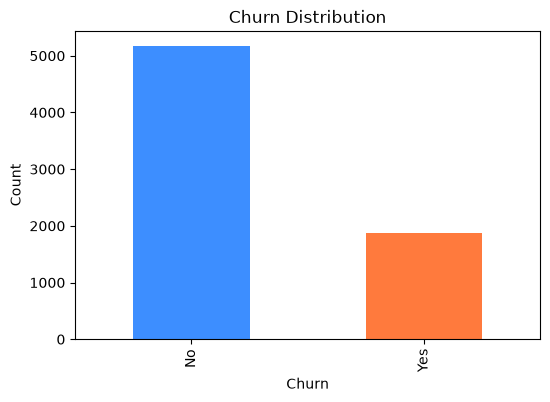

In [10]:
# Bar chart
plt.figure(figsize=(6,4))
churn_counts.plot(kind='bar', color=['#3D8EFF','#FF7A3D'])
plt.title('Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Count')
plt.savefig('reports/churn_distribution_bar.png')
plt.show()

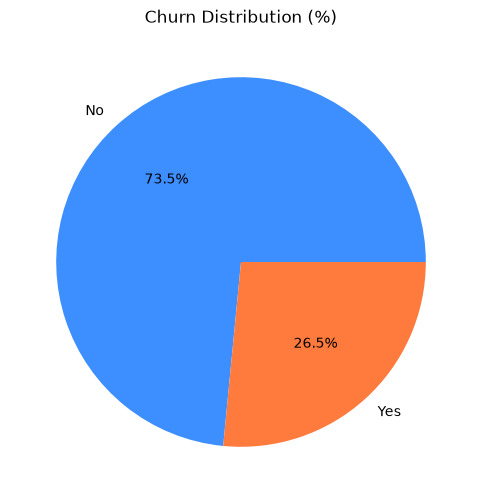

In [11]:
# Pie chart
plt.figure(figsize=(6,6))
churn_counts.plot(kind='pie', autopct='%1.1f%%', colors=['#3D8EFF','#FF7A3D'])
plt.title('Churn Distribution (%)')
plt.savefig('reports/churn_distribution_pie.png')
plt.show()

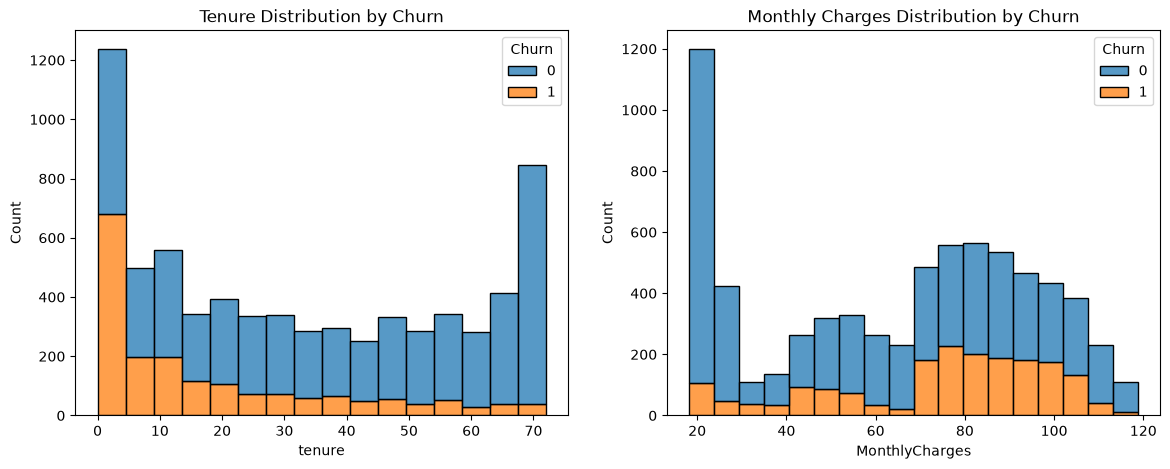

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

sns.histplot(data=df, x='tenure', hue='Churn', multiple='stack', ax=axes[0])
axes[0].set_title('Tenure Distribution by Churn')

sns.histplot(data=df, x='MonthlyCharges', hue='Churn', multiple='stack', ax=axes[1])
axes[1].set_title('Monthly Charges Distribution by Churn')

plt.savefig('reports/distributions_by_churn.png')
plt.show()

In [13]:
ct = df.groupby('Contract')['Churn'].apply(lambda x: (x=='Yes').mean()*100)
print(ct.round(1))

Contract
Month-to-month    0.0
One year          0.0
Two year          0.0
Name: Churn, dtype: float64


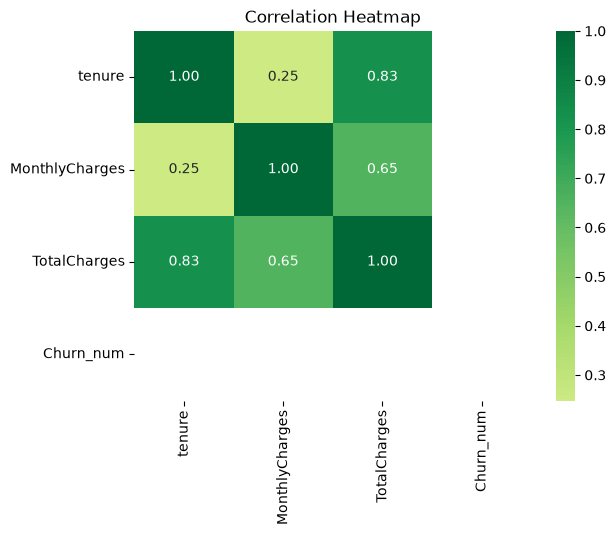

In [14]:
df_c = df.copy()
df_c['Churn_num'] = (df_c['Churn']=='Yes').astype(int)
corr = df_c[['tenure','MonthlyCharges','TotalCharges','Churn_num']].corr()

sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn', center=0)
plt.title('Correlation Heatmap')
plt.savefig('reports/correlation_heatmap.png')
plt.show()

In [15]:
df.drop('customerID', axis=1, inplace=True)

In [16]:
X = df.drop(columns=['Churn'])
y = df['Churn']

num_cols = X.select_dtypes(include=['int64','float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['object']).columns.tolist()

print(f"Numerical columns: {num_cols}")
print(f"Categorical columns: {cat_cols}")

Numerical columns: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Categorical columns: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


C:\Users\Tatai & Papai\AppData\Local\Temp\ipykernel_15200\2790029705.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include=['object']).columns.tolist()


In [17]:
print(f"Total numerical: {len(num_cols)}")
print(f"Total categorical: {len(cat_cols)}")

Total numerical: 4
Total categorical: 15


In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,      # 80% train, 20% test
    stratify=y,         # keeps same 26.5% churn ratio in both sets
    random_state=42     # ensures same split every time you run
)

print(f"Train: {X_train.shape}")
print(f"Test:  {X_test.shape}")
print(f"Train churn %: {y_train.mean()*100:.1f}%")
print(f"Test churn  %: {y_test.mean()*100:.1f}%")

Train: (5634, 19)
Test:  (1409, 19)
Train churn %: 26.5%
Test churn  %: 26.5%


In [19]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
])

print("Preprocessor built successfully!")

Preprocessor built successfully!


In [20]:
# New feature 1: tenure group
df['tenure_group'] = pd.cut(df['tenure'],
    bins=[0, 12, 24, 48, 72],
    labels=['New', 'Young', 'Mature', 'Loyal'])

# New feature 2: monthly charges per tenure
df['monthly_per_tenure'] = df['MonthlyCharges'] / (df['tenure'] + 1)

# New feature 3: total number of services
service_cols = ['PhoneService', 'OnlineSecurity', 'OnlineBackup',
                'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
df['num_services'] = (df[service_cols] == 'Yes').sum(axis=1)

print(df[['tenure', 'tenure_group', 'monthly_per_tenure', 'num_services']].head(10))

   tenure tenure_group  monthly_per_tenure  num_services
0       1          New           14.925000             1
1      34       Mature            1.627143             3
2       2          New           17.950000             3
3      45       Mature            0.919565             3
4       2          New           23.566667             1
5       8          New           11.072222             4
6      22        Young            3.873913             3
7      10          New            2.704545             1
8      28       Mature            3.613793             5
9      62        Loyal            0.891270             3


In [21]:
import os
os.makedirs('data/processed', exist_ok=True)

X_train.to_csv('data/processed/X_train.csv', index=False)
X_test.to_csv('data/processed/X_test.csv', index=False)
y_train.to_csv('data/processed/y_train.csv', index=False)
y_test.to_csv('data/processed/y_test.csv', index=False)

print("Data saved successfully!")

Data saved successfully!


In [22]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score, classification_report
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
import warnings
warnings.filterwarnings('ignore')


In [23]:
X_train = pd.read_csv('data/processed/X_train.csv')
X_test = pd.read_csv('data/processed/X_test.csv')
y_train = pd.read_csv('data/processed/y_train.csv').squeeze()
y_test = pd.read_csv('data/processed/y_test.csv').squeeze()

print(f"Train: {X_train.shape}")
print(f"Test: {X_test.shape}")

Train: (5634, 19)
Test: (1409, 19)


In [24]:
models = {
    'Logistic Regression': LogisticRegression(class_weight='balanced', random_state=42),
    'Decision Tree':       DecisionTreeClassifier(class_weight='balanced', random_state=42),
    'Random Forest':       RandomForestClassifier(class_weight='balanced', random_state=42),
    'Gradient Boosting':   GradientBoostingClassifier(random_state=42),
    'XGBoost':             XGBClassifier(random_state=42, eval_metric='logloss')
}

print(f"Total models to train: {len(models)}")

Total models to train: 5


In [25]:
results = []

for name, model in models.items():
    # Build pipeline
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    
    # Train
    pipeline.fit(X_train, y_train)
    
    # Predict
    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]
    
    # Scores
    results.append({
        'Model': name,
        'AUC':       round(roc_auc_score(y_test, y_prob), 4),
        'F1':        round(f1_score(y_test, y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred), 4),
        'Recall':    round(recall_score(y_test, y_pred), 4)
    })
    print(f"✅ {name} done")
    
# Show results table
results_df = pd.DataFrame(results).sort_values('AUC', ascending=False)
print("\n")
print(results_df.to_string(index=False))

✅ Logistic Regression done
✅ Decision Tree done
✅ Random Forest done
✅ Gradient Boosting done
✅ XGBoost done


              Model    AUC     F1  Precision  Recall
  Gradient Boosting 0.8432 0.5895     0.6735  0.5241
Logistic Regression 0.8413 0.6136     0.5043  0.7834
            XGBoost 0.8254 0.5726     0.6060  0.5428
      Random Forest 0.8208 0.5856     0.5566  0.6176
      Decision Tree 0.6537 0.4906     0.4946  0.4866


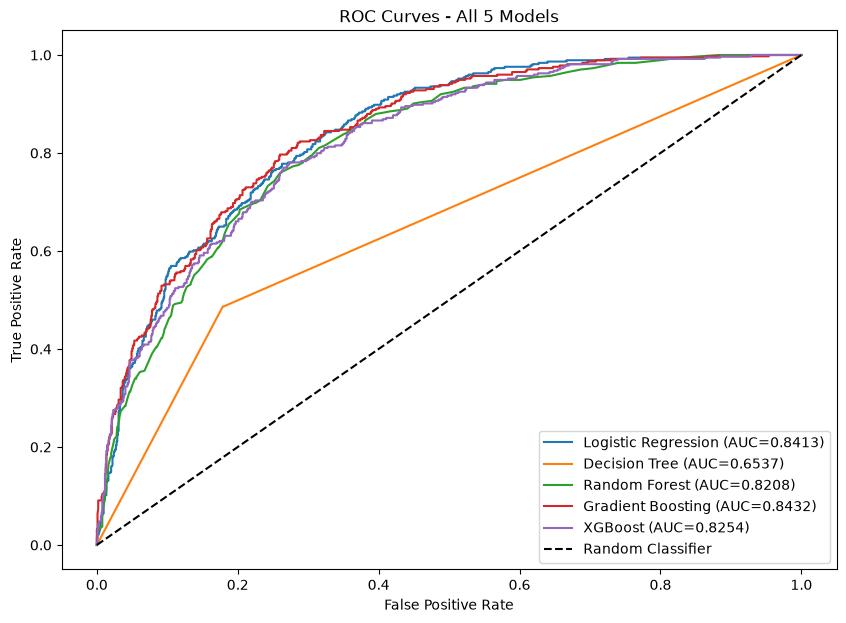

In [26]:
from sklearn.metrics import roc_curve

plt.figure(figsize=(10, 7))

for name, model in models.items():
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    pipeline.fit(X_train, y_train)
    y_prob = pipeline.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.4f})')

plt.plot([0,1], [0,1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - All 5 Models')
plt.legend(loc='lower right')
plt.savefig('reports/roc_curves.png', bbox_inches='tight')
plt.show()

In [27]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'classifier__n_estimators': [50, 100, 150, 200],
    'classifier__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'classifier__max_depth': [2, 3, 4, 5],
    'classifier__min_samples_split': [2, 5, 10]
}

random_search = RandomizedSearchCV(
    Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', GradientBoostingClassifier(random_state=42))
    ]),
    param_distributions=param_dist,
    n_iter=20,          # tries 20 random combinations
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

random_search.fit(X_train, y_train)
print(f"Best Parameters (RandomizedSearch): {random_search.best_params_}")
print(f"Best CV AUC (RandomizedSearch): {random_search.best_score_:.4f}")

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Parameters (RandomizedSearch): {'classifier__n_estimators': 100, 'classifier__min_samples_split': 5, 'classifier__max_depth': 3, 'classifier__learning_rate': 0.05}
Best CV AUC (RandomizedSearch): 0.8483


In [28]:
from sklearn.model_selection import GridSearchCV

best_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', GradientBoostingClassifier(random_state=42))
])

param_grid = {
    'classifier__n_estimators': [100, 200],
    'classifier__learning_rate': [0.05, 0.1],
    'classifier__max_depth': [3, 5]
}

grid_search = GridSearchCV(
    best_pipeline,
    param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best CV AUC (GridSearch): {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best Parameters: {'classifier__learning_rate': 0.05, 'classifier__max_depth': 3, 'classifier__n_estimators': 100}
Best CV AUC (GridSearch): 0.8484


Test AUC:       0.8457
Test F1:        0.5771
Test Precision: 0.6726
Test Recall:    0.5053

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.84      0.91      0.87      1035
       Churn       0.67      0.51      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409



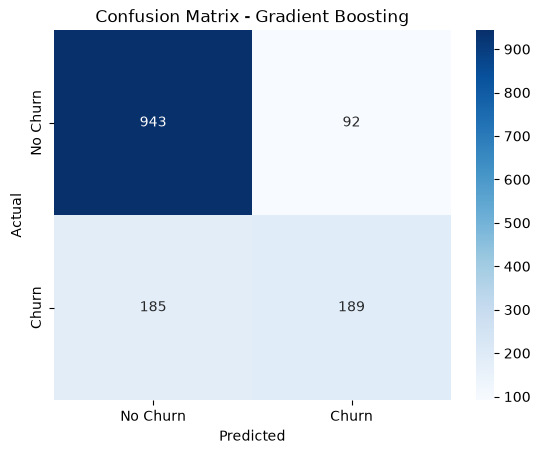

In [29]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.makedirs('reports', exist_ok=True)

# Get best model
final_model = grid_search.best_estimator_

# Predictions
y_pred = final_model.predict(X_test)
y_prob = final_model.predict_proba(X_test)[:, 1]

# Scores
print(f"Test AUC:       {roc_auc_score(y_test, y_prob):.4f}")
print(f"Test F1:        {f1_score(y_test, y_pred):.4f}")
print(f"Test Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Test Recall:    {recall_score(y_test, y_pred):.4f}")

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
plt.title('Confusion Matrix - Gradient Boosting')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.savefig('reports/confusion_matrix.png')
plt.show()



### Best Model: Gradient Boosting (after GridSearchCV tuning)

### Best Hyperparameters:
- `learning_rate = 0.05`
- `max_depth = 3`
- `n_estimators = 100`

### Test Set Performance:
| Metric    | Score  |
|-----------|--------|
| AUC       | 0.8457 |
| F1        | 0.5771 |
| Precision | 0.6726 |
| Recall    | 0.5053 |
| Accuracy  | 0.80   |

### Classification Report:
| Class       | Precision | Recall | F1   | Support |
|-------------|-----------|--------|------|---------|
| No Churn    | 0.84      | 0.91   | 0.87 | 1035    |
| Churn       | 0.67      | 0.51   | 0.58 | 374     |
| Macro Avg   | 0.75      | 0.71   | 0.72 | 1409    |
| Weighted Avg| 0.79      | 0.80   | 0.79 | 1409    |

### Business Insights:
- Model correctly identifies **91%** of non-churners
- Model catches **51%** of actual churners (185 missed out of 374)
- When model predicts churn, it is correct **67%** of the time
- Class imbalance (26.5% churners) is the main reason recall is low on churn class
- AUC of **0.8457** means the model is strong at ranking churners vs non-churners

In [30]:
import joblib
import os

os.makedirs('models', exist_ok=True)

joblib.dump(final_model, 'models/best_model.pkl')
print("Model saved successfully!")

#  Loads the model
loaded_model = joblib.load('models/best_model.pkl')
test_pred = loaded_model.predict(X_test[:5])
print(f"Test predictions: {test_pred}")

Model saved successfully!
Test predictions: [0 1 0 0 0]


In [31]:
import shap

os.makedirs('reports', exist_ok=True)

# Load saved model
final_model = joblib.load('models/best_model.pkl')

# Load processed data
X_test = pd.read_csv('data/processed/X_test.csv')
y_test = pd.read_csv('data/processed/y_test.csv').squeeze()

# Extract preprocessor and classifier
preprocessor = final_model.named_steps['preprocessor']
classifier = final_model.named_steps['classifier']

# Transform test data
X_test_transformed = preprocessor.transform(X_test)

# Create SHAP explainer
explainer = shap.TreeExplainer(classifier)
shap_values = explainer.shap_values(X_test_transformed)

print("Everything loaded successfully!")
print(f"X_test transformed shape: {X_test_transformed.shape}")
print(f"SHAP values shape: {shap_values.shape}")

Everything loaded successfully!
X_test transformed shape: (1409, 45)
SHAP values shape: (1409, 45)




### Data Shape After Preprocessing:
- **Test customers:** 1409
- **Features after OneHotEncoding:** 45
  - Original features: 19
  - Expanded to 45 after encoding categorical columns into dummy variables

### Why SHAP?
- Model accuracy alone doesn't explain **why** a prediction was made
- SHAP (SHapley Additive exPlanations) tells us **which features** pushed 
  a customer towards churn or no churn
- Helps business teams take **action** — not just see a prediction

### Types of SHAP Charts we will plot:
| Chart | Purpose |
|-------|---------|
| Summary Plot | Shows impact of every feature on every customer |
| Bar Plot | Shows overall top features by importance |
| Waterfall Plot | Explains prediction for one specific customer |

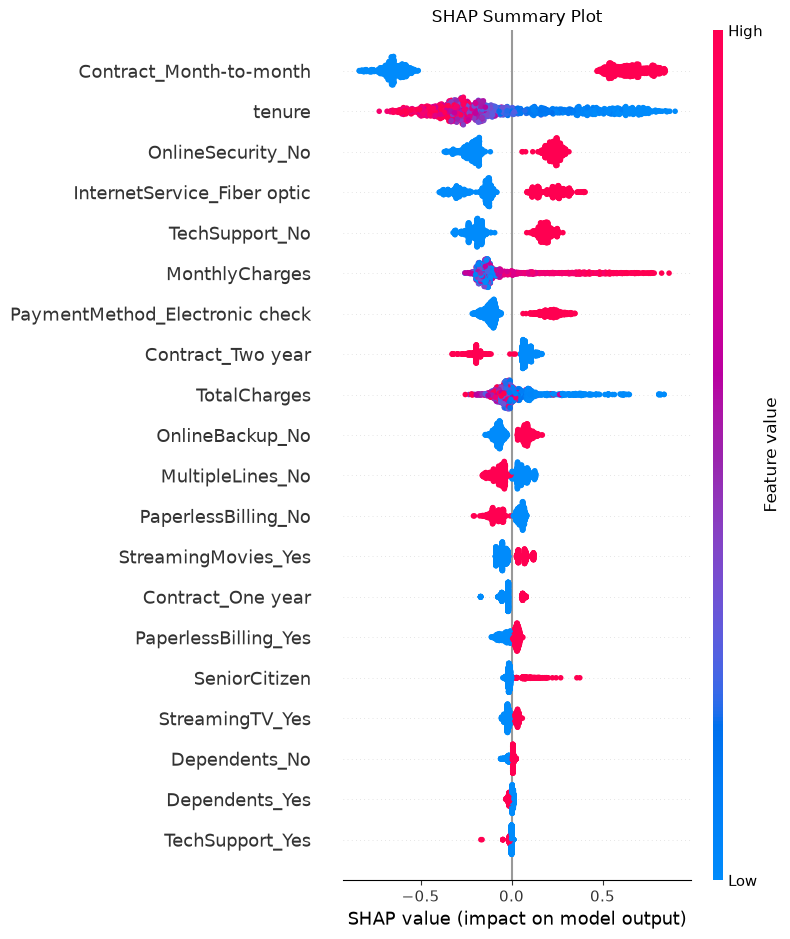

In [32]:
# Get feature names after transformation
cat_feature_names = preprocessor.named_transformers_['cat']\
    .get_feature_names_out(X_test.select_dtypes(include='object').columns.tolist())
num_feature_names = X_test.select_dtypes(include=['int64','float64']).columns.tolist()
all_feature_names = num_feature_names + list(cat_feature_names)

# SHAP Summary Plot
shap.summary_plot(shap_values, X_test_transformed,
                  feature_names=all_feature_names,
                  show=False)
plt.title('SHAP Summary Plot')
plt.tight_layout()
plt.savefig('reports/shap_summary.png', bbox_inches='tight')
plt.show()

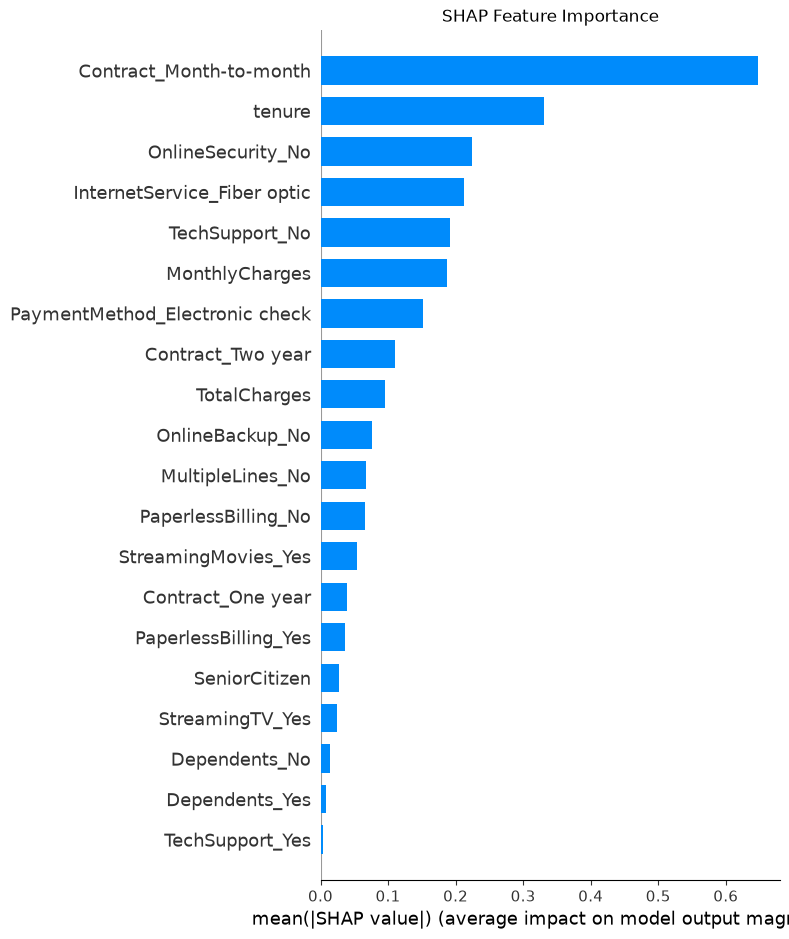

In [33]:
shap.summary_plot(shap_values, X_test_transformed,
                  feature_names=all_feature_names,
                  plot_type='bar',
                  show=False)
plt.title('SHAP Feature Importance')
plt.tight_layout()
plt.savefig('reports/shap_importance.png', bbox_inches='tight')
plt.show()

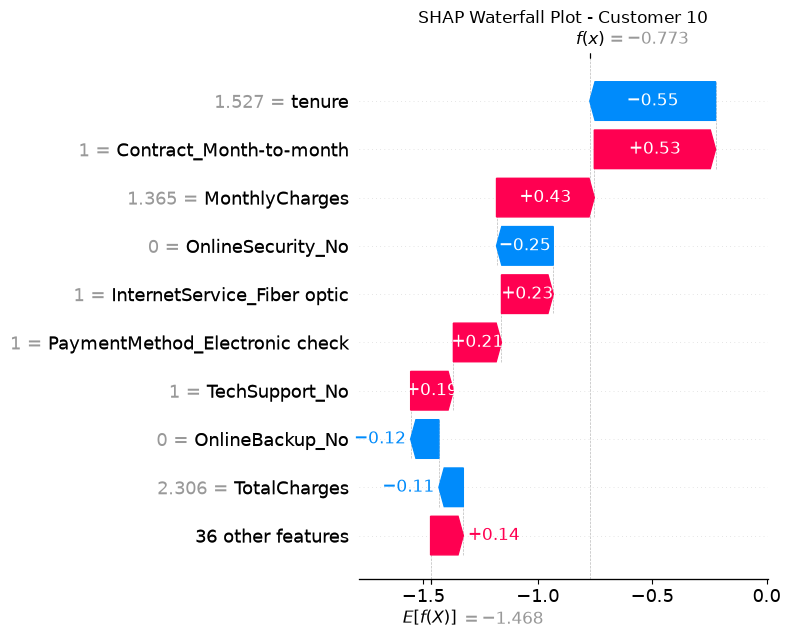

Actual:    No Churn
Predicted: No Churn


In [34]:
customer_index = 10

# Fix: extract scalar from expected_value
base_val = explainer.expected_value
if hasattr(base_val, '__len__'):
    base_val = float(base_val[0])
else:
    base_val = float(base_val)

explanation = shap.Explanation(
    values=shap_values[customer_index].astype(float),
    base_values=base_val,
    data=X_test_transformed[customer_index].astype(float),
    feature_names=all_feature_names
)

shap.plots.waterfall(explanation, show=False)
plt.title(f'SHAP Waterfall Plot - Customer {customer_index}')
plt.tight_layout()
plt.savefig('reports/shap_waterfall.png', bbox_inches='tight')
plt.show()

# Check actual vs predicted
print(f"Actual:    {'Churn' if y_test.iloc[customer_index]==1 else 'No Churn'}")
print(f"Predicted: {'Churn' if final_model.predict(X_test.iloc[[customer_index]])[0]==1 else 'No Churn'}")


### Plot 1: SHAP Summary Plot
- `Contract_Month-to-month` is the strongest churn driver
- High `tenure` strongly reduces churn risk
- Customers without `OnlineSecurity` and `TechSupport` are at higher risk
- High `MonthlyCharges` pushes customers towards churn
- `InternetService_Fiber optic` customers churn more than DSL customers

### Plot 2: SHAP Feature Importance (Bar Plot)
| Rank | Feature | Importance |
|------|---------|------------|
| 1 | Contract_Month-to-month | 0.63 |
| 2 | tenure | 0.33 |
| 3 | OnlineSecurity_No | 0.22 |
| 4 | InternetService_Fiber optic | 0.21 |
| 5 | TechSupport_No | 0.20 |

### Plot 3: SHAP Waterfall Plot (Customer 10)
- **Actual:** No Churn ✅ **Predicted:** No Churn ✅
- High tenure (-0.55) outweighed month-to-month contract (+0.53)
- Model correctly identified this customer as low risk
- Business insight: long-term customers stay despite risk factors